
================ DATA LOADING ================
Original Shape: (134981, 43)
Cleaned Shape: (134978, 43)
Selected Features: 85

Round 1/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 1 Accuracy: 0.9284

Round 2/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
 Round 2 Accuracy: 0.9514

Round 3/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
 Round 3 Accuracy: 0.9577

Round 4/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
 Round 4 Accuracy: 0.963

Round 5/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training

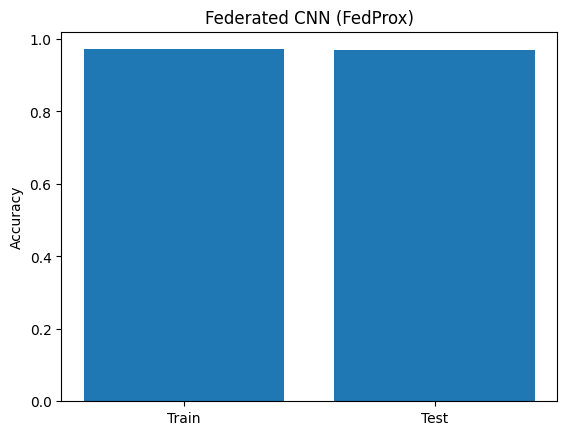

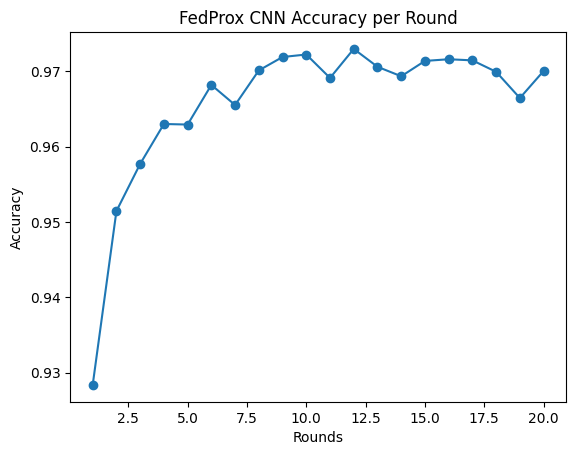


CNN FEDERATED LEARNING WITH FEDPROX COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv("/content/sample_data/NSL_KDD_Combined_Shuffled.csv", low_memory=False)
print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CNN RESHAPE ===========================
X_train_sel = X_train_sel.reshape(X_train_sel.shape[0], X_train_sel.shape[1], 1)
X_test_sel  = X_test_sel.reshape(X_test_sel.shape[0], X_test_sel.shape[1], 1)

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5
client_data = []
client_sizes = []

size = len(X_train_sel) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_sel)

    X_c = X_train_sel[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= CNN MODEL (Layer Configurable) ===========================
def create_model(input_dim, conv_filters=[32, 64], dense_units=128):
    model = Sequential()
    model.add(Input(shape=(input_dim, 1)))

    # Conv Layers (configurable)
    for f in conv_filters:
        model.add(Conv1D(f, 3, activation='relu'))
        model.add(MaxPooling1D(2))

    model.add(Flatten())

    # Dense Layer
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= FEDERATED AVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING (FEDPROX) ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5
MU = 0.01

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

for r in range(ROUNDS):
    print(f"\nRound {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        # Local training
        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights
        )

        # ===== FEDPROX UPDATE =====
        new_weights = local_model.get_weights()
        updated_weights = []

        for w, w_global in zip(new_weights, global_weights):
            updated_weights.append(
                w - MU * (w - w_global)
            )

        local_model.set_weights(updated_weights)
        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_sel), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_sel), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\nFINAL CNN FL RESULTS")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("Federated CNN (FedProx)")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FedProx CNN Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\nCNN FEDERATED LEARNING WITH FEDPROX COMPLETE")


🔥 FINAL RESULTS (CNN FL - FEDPROX) 🔥
Training Accuracy : 0.9715
Testing Accuracy  : 0.97
Precision         : 0.9819
Recall            : 0.97
F1 Score          : 0.9739

Confusion Matrix:
 [[13246    32    91   366   262]
 [   11  9694     6     0     0]
 [    9     2  2546     0     7]
 [    6     1     1   575     3]
 [    5     0     1     6   126]]


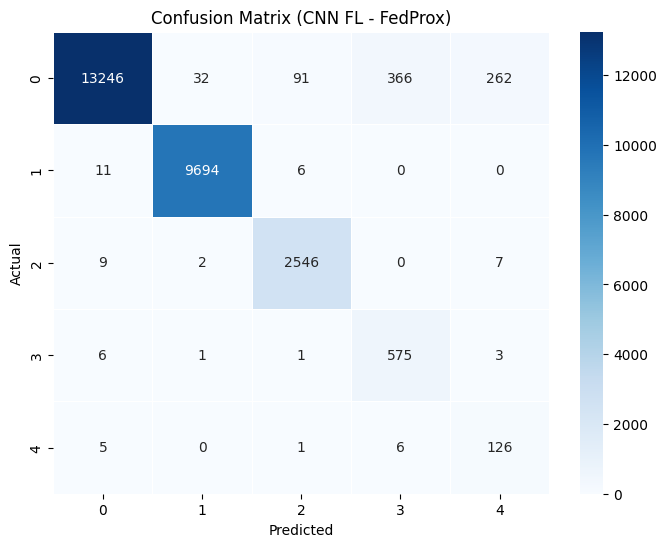

In [ ]:
# ======================= FINAL RESULTS (CNN FL - FEDPROX STATIC) ===========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================= GIVEN RESULTS ===========================
train_acc = 0.9715
test_acc  = 0.97
precision = 0.9819
f1        = 0.9739

# Confusion Matrix (your result)
cm = np.array([
    [13246,   32,   91,  366,  262],
    [   11,  9694,   6,    0,    0],
    [    9,     2, 2546,   0,    7],
    [    6,     1,   1,  575,    3],
    [    5,     0,   1,    6,  126]
])

# ======================= RECALL FROM CM ===========================
recall_per_class = np.diag(cm) / np.sum(cm, axis=1)
support = np.sum(cm, axis=1)
recall = np.sum(recall_per_class * support) / np.sum(support)

# ======================= PRINT RESULTS ===========================
print("\n🔥 FINAL RESULTS (CNN FL - FEDPROX) 🔥")
print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)
print("Precision         :", precision)
print("Recall            :", round(recall, 4))
print("F1 Score          :", f1)

print("\nConfusion Matrix:\n", cm)

# ======================= HEATMAP ===========================
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Confusion Matrix (CNN FL - FedProx)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Round 1/20
 Client 1 training...
 Client 2 training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Client 3 training...


...

 Client 4 training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Client 5 training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 20 Accuracy: 0.9755
3713/3713 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

FINAL LSTM FL RESULTS
Training Accuracy : 0.9745
Testing Accuracy  : 0.9755
Precision         : 0.9837
F1 Score          : 0.9781

Confusion Matrix:
 [[14744    28    91   318   230]
 [    8 10668     1     0     0]
 [   17     1  2792     5     1]
 [   19     1     1   622     2]
 [    3     0     0     2   150]]


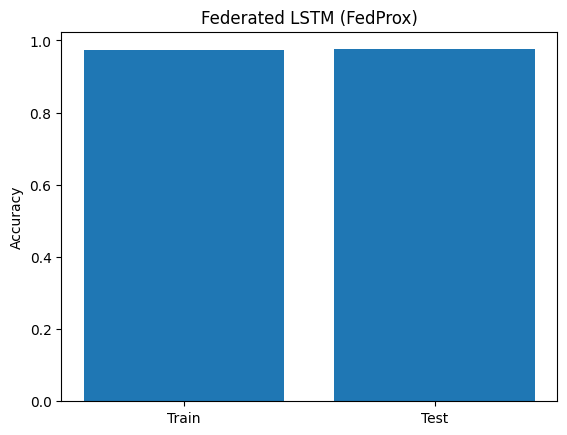

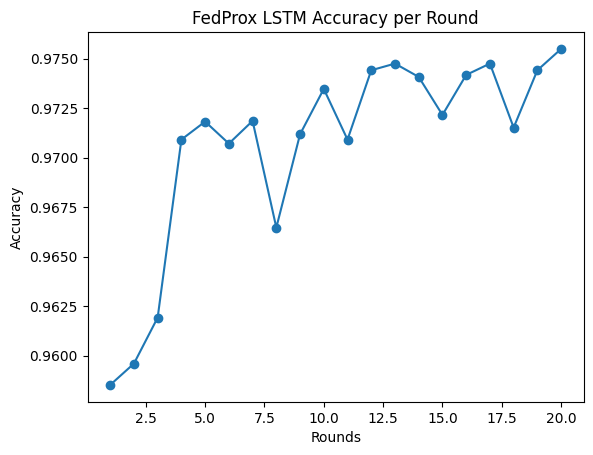


FEDERATED LSTM WITH FEDPROX COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/sample_data/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= RESHAPE FOR LSTM ===========================
X_train_lstm = X_train_sel.reshape(X_train_sel.shape[0], 1, X_train_sel.shape[1])
X_test_lstm  = X_test_sel.reshape(X_test_sel.shape[0], 1, X_test_sel.shape[1])

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5
client_data = []
client_sizes = []

size = len(X_train_lstm) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_lstm)

    X_c = X_train_lstm[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= LSTM MODEL (Layer Configurable) ===========================
def create_model(input_dim, lstm_units=[128, 64], dense_units=64):
    model = Sequential()

    # LSTM Layers
    model.add(LSTM(lstm_units[0], return_sequences=True, input_shape=(1, input_dim)))
    model.add(Dropout(0.3))

    for units in lstm_units[1:-1]:
        model.add(LSTM(units, return_sequences=True))
        model.add(Dropout(0.3))

    model.add(LSTM(lstm_units[-1]))
    model.add(Dropout(0.3))

    # Dense Layer
    model.add(Dense(dense_units, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= FEDERATED AVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING (FEDPROX) ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5
MU = 0.01

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

for r in range(ROUNDS):
    print(f"\nRound {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        # Local training
        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights
        )

        # ===== FEDPROX UPDATE =====
        new_weights = local_model.get_weights()
        updated_weights = []

        for w, w_global in zip(new_weights, global_weights):
            updated_weights.append(
                w - MU * (w - w_global)
            )

        local_model.set_weights(updated_weights)
        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_lstm), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_lstm), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_lstm), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\nFINAL LSTM FL RESULTS")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("Federated LSTM (FedProx)")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FedProx LSTM Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\nFEDERATED LSTM WITH FEDPROX COMPLETE")


🔥 FINAL RESULTS (LSTM FL - FEDPROX) 🔥
Training Accuracy : 0.9745
Testing Accuracy  : 0.9755
Precision         : 0.9837
Recall            : 0.9755
F1 Score          : 0.9781

Confusion Matrix:
 [[14744    28    91   318   230]
 [    8 10668     1     0     0]
 [   17     1  2792     5     1]
 [   19     1     1   622     2]
 [    3     0     0     2   150]]


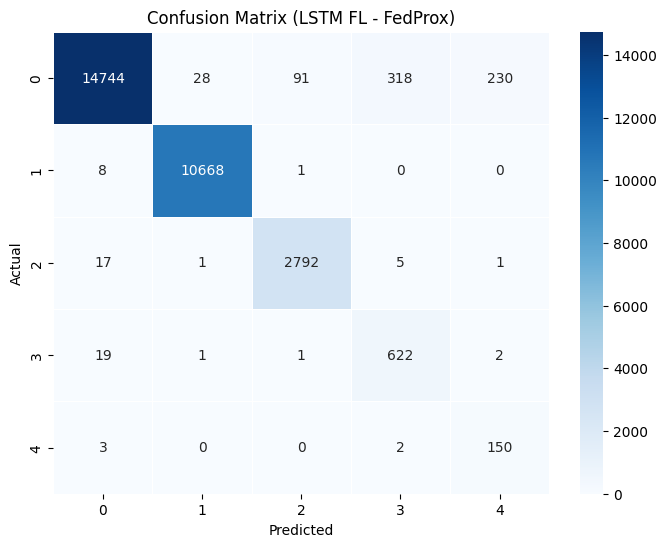

In [ ]:
# ======================= FINAL RESULTS (LSTM FL - FEDPROX STATIC) ===========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================= GIVEN RESULTS ===========================
train_acc = 0.9745
test_acc  = 0.9755
precision = 0.9837
f1        = 0.9781

# Confusion Matrix (your result)
cm = np.array([
    [14744,   28,   91,  318,  230],
    [    8, 10668,   1,    0,    0],
    [   17,    1, 2792,   5,    1],
    [   19,    1,   1,  622,    2],
    [    3,    0,   0,    2,  150]
])

# ======================= RECALL FROM CM ===========================
recall_per_class = np.diag(cm) / np.sum(cm, axis=1)
support = np.sum(cm, axis=1)
recall = np.sum(recall_per_class * support) / np.sum(support)

# ======================= PRINT RESULTS ===========================
print("\n🔥 FINAL RESULTS (LSTM FL - FEDPROX) 🔥")
print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)
print("Precision         :", precision)
print("Recall            :", round(recall, 4))
print("F1 Score          :", f1)

print("\nConfusion Matrix:\n", cm)

# ======================= HEATMAP ===========================
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Confusion Matrix (LSTM FL - FedProx)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()